# SofaScore ratings vs derived Kickbase points — last five matches

Uses the newest JSON recording of each dataset, selected by its `generated_at` timestamp. The window is each team's last five **overall matches** (all competitions), taken from the rating export's recorded team-form source. It is not the player's last five appearances. Only players retained by the source exports' eligibility rules are available.

The scatter plots compare ratings with estimated points, first per match and then as player averages over **the same matched games**. The player view places both series on separate, labelled axes. Missing ratings or points remain gaps, never zeros. Kickbase points are SofaScore-based approximations, including proxy awards, rather than official Kickbase results.


In [1]:
import json
import sys
from datetime import datetime, timezone
from pathlib import Path

import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display


def locate_project_root():
    for start in (Path.cwd().resolve(), Path(globals().get('__vsc_ipynb_file__', '.')).resolve()):
        for candidate in (start, *start.parents):
            if (candidate / 'project_paths.py').is_file():
                return candidate
    raise FileNotFoundError('Could not locate project_paths.py. Run from the project directory.')


PROJECT_ROOT = locate_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from project_paths import (
    SOFASCORE_PLAYER_AVERAGE_RATINGS_DIR,
    SOFASCORE_PLAYER_KICKBASE_POINT_AVERAGES_DIR,
    SOFASCORE_TEAM_FORM_DIR,
)


def latest_recording(directory, pattern):
    candidates = []
    for path in directory.glob(pattern):
        payload = json.loads(path.read_text(encoding='utf-8'))
        timestamp = datetime.fromisoformat(payload['generated_at'].replace('Z', '+00:00'))
        if timestamp.tzinfo is None:
            timestamp = timestamp.replace(tzinfo=timezone.utc)
        candidates.append((timestamp, path.name, path, payload))
    if not candidates:
        raise FileNotFoundError(f'No {pattern} found in {directory}. Run the source notebook first.')
    _, _, path, payload = max(candidates, key=lambda item: item[:2])
    return path, payload


rating_path, ratings = latest_recording(SOFASCORE_PLAYER_AVERAGE_RATINGS_DIR, 'team_player_average_ratings_*.json')
points_path, points = latest_recording(SOFASCORE_PLAYER_KICKBASE_POINT_AVERAGES_DIR, 'overall_player_kickbase_point_averages_*.json')
for label, path, payload in [('Ratings', rating_path, ratings), ('Derived points', points_path, points)]:
    print(f'{label}: {path.name}\n  Recorded: {payload["generated_at"]}\n  Team-form source: {payload["source_file"]}')
if ratings['source_file'] != points['source_file']:
    print('WARNING: Latest exports use different team histories. Only identical player/match IDs are compared; the rating source defines the five-match window.')
form_path = SOFASCORE_TEAM_FORM_DIR / Path(ratings['source_file']).name
if not form_path.is_file():
    raise FileNotFoundError(f'The recorded team-form source is required to identify the last five games: {form_path}')
form_document = json.loads(form_path.read_text(encoding='utf-8'))
form_teams = form_document[max(form_document, key=lambda value: datetime.fromisoformat(value))]


Ratings: team_player_average_ratings_2026-09-10_13-04-32_944696+0200.json
  Recorded: 2026-09-10T13:04:32+02:00
  Team-form source: team_form_2026-09-10_13-03-24_642850+0200.json
Derived points: overall_player_kickbase_point_averages_2026-09-10_13-07-08_654246+0200.json
  Recorded: 2026-09-10T13:07:08+02:00
  Team-form source: team_form_2026-09-10_13-03-24_642850+0200.json


In [2]:
def flatten_players(payload, collection, value_field, output_field):
    rows = []
    for team_id, team in payload['teams'].items():
        for player in team.get('overall', {}).get('players', []):
            for match in player.get(collection, []):
                rows.append({'team_id': str(team_id), 'player_id': int(player['player_id']),
                             'match_id': int(match['match_id']), 'player_name': player['player_name'],
                             output_field: match.get(value_field)})
    frame = pd.DataFrame(rows, columns=['team_id', 'player_id', 'match_id', 'player_name', output_field])
    if frame.duplicated(['team_id', 'player_id', 'match_id']).any():
        raise ValueError(f'Duplicate player/match records in {output_field} export.')
    frame[output_field] = pd.to_numeric(frame[output_field], errors='coerce')
    return frame


rating_rows = flatten_players(ratings, 'ratings', 'rating', 'rating')
point_rows = flatten_players(points, 'match_calculations', 'calculated_kickbase_points', 'points')
window_rows = []
for team_id, team in form_teams.items():
    matches = sorted(team['overall_matches'], key=lambda match: pd.Timestamp(match['date']))[-5:]
    for slot, match in enumerate(matches, 1):
        window_rows.append({'team_id': str(team_id), 'team': team['team'],
                            'match_id': int(match['match_id']), 'slot': slot,
                            'date': match['date'], 'fixture': f"{match['home_team']} vs {match['away_team']}",
                            'competition': match.get('competition', '')})
windows = pd.DataFrame(window_rows)
windows['date'] = pd.to_datetime(windows['date'], utc=True)
keys = ['team_id', 'player_id', 'match_id']
roster = pd.concat([rating_rows[['team_id', 'player_id', 'player_name']],
                    point_rows[['team_id', 'player_id', 'player_name']]]).drop_duplicates(['team_id', 'player_id'])
comparison = roster.merge(windows, on='team_id', validate='many_to_many')
comparison = comparison.merge(rating_rows[keys + ['rating']], on=keys, how='left', validate='one_to_one')
comparison = comparison.merge(point_rows[keys + ['points']], on=keys, how='left', validate='one_to_one')
comparison = comparison.sort_values(['team', 'player_name', 'date']).reset_index(drop=True)
matched = comparison.dropna(subset=['rating', 'points']).copy()
if matched.empty:
    raise ValueError('No matching player/match pairs with both a rating and derived points.')
print(f'{len(matched):,} paired player/matches across {matched[["team_id", "player_id"]].drop_duplicates().shape[0]} players.')
print(f'Rating only: {(comparison.rating.notna() & comparison.points.isna()).sum()} | '
      f'Points only: {(comparison.rating.isna() & comparison.points.notna()).sum()} | '
      f'Neither recorded: {(comparison.rating.isna() & comparison.points.isna()).sum()}')
print(f'Failed point fetches recorded in source: {len(points.get("failed_matches", []))}')


1,012 paired player/matches across 330 players.
Rating only: 24 | Points only: 23 | Neither recorded: 671
Failed point fetches recorded in source: 22


## Ratings and points across the five-match window
Each dot in the first graph is one player in one game. Hover for the player, fixture and match ID. The second graph averages each player's paired observations only, so both averages use identical games. Correlations describe association, not predictive accuracy.


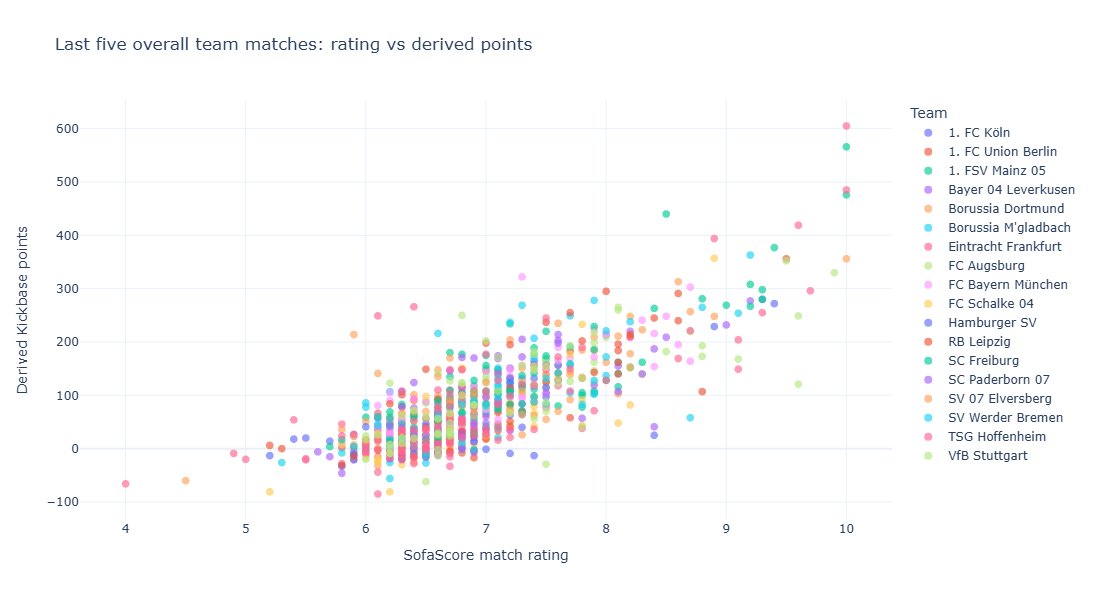

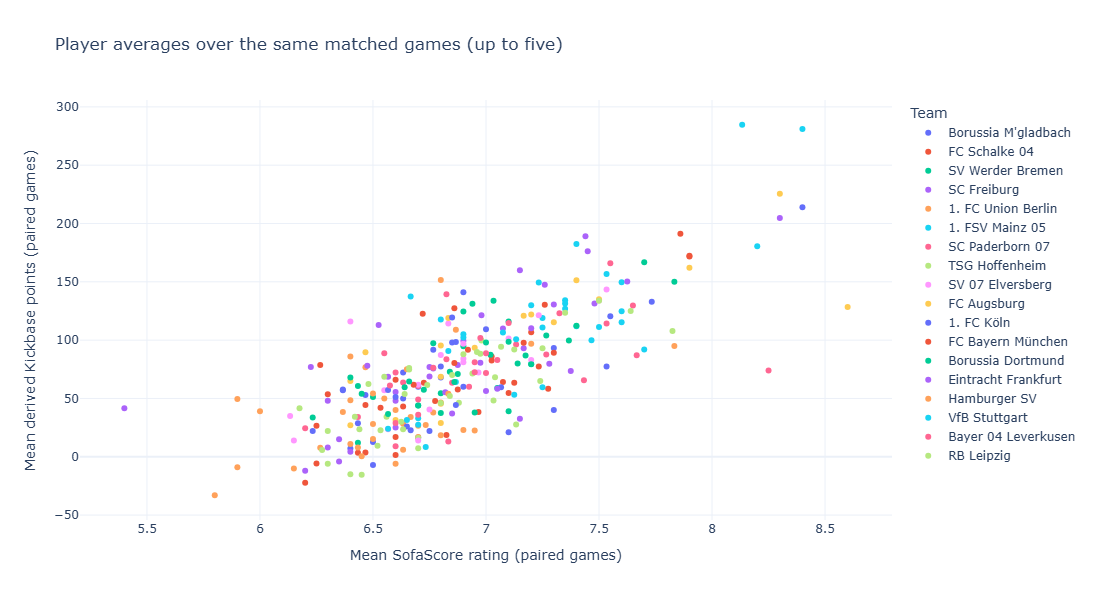

Per-match Pearson correlation: 0.791
Player-average Pearson correlation: 0.757


,team_id,player_id,team,player_name,average_rating,average_points,paired_matches
0,2556,327755,1. FSV Mainz 05,Nadiem Amiri,8.133333,284.666667,3
1,2556,822340,1. FSV Mainz 05,Phillip Tietz,8.400000,281.000000,3
2,2600,1129365,FC Augsburg,Anton Kade,8.300000,225.500000,2
3,2527,1142210,Borussia M'gladbach,Hugo Bolin,8.400000,214.000000,3
4,2538,1019321,SC Freiburg,Igor Matanović,8.300000,204.800000,5
...,...,...,...,...,...,...,...
325,2674,40239,Eintracht Frankfurt,Timothy Chandler,6.200000,-12.000000,1
326,36360,1414933,RB Leipzig,Marc Guiu,6.400000,-15.000000,1
327,2569,67647,TSG Hoffenheim,Andrej Kramarić,6.450000,-15.500000,2
328,2530,794962,FC Schalke 04,Maximilian Wöber,6.200000,-22.333333,3


In [3]:
fig_matches = px.scatter(matched, x='rating', y='points', color='team',
    hover_name='player_name', hover_data=['match_id', 'fixture', 'date', 'competition'],
    labels={'rating': 'SofaScore match rating', 'points': 'Derived Kickbase points', 'team': 'Team'},
    title='Last five overall team matches: rating vs derived points', template='plotly_white')
fig_matches.update_traces(marker={'size': 8, 'opacity': 0.65})
fig_matches.update_layout(height=600)
fig_matches.show()

averages = matched.groupby(['team_id', 'player_id', 'team', 'player_name'], as_index=False).agg(
    average_rating=('rating', 'mean'), average_points=('points', 'mean'), paired_matches=('match_id', 'nunique'))
fig_averages = px.scatter(averages, x='average_rating', y='average_points', color='team',
    hover_name='player_name', hover_data=['paired_matches'],
    labels={'average_rating': 'Mean SofaScore rating (paired games)',
            'average_points': 'Mean derived Kickbase points (paired games)', 'team': 'Team'},
    title='Player averages over the same matched games (up to five)', template='plotly_white')
fig_averages.update_layout(height=600)
fig_averages.show()
print(f'Per-match Pearson correlation: {matched.rating.corr(matched.points):.3f}')
print(f'Player-average Pearson correlation: {averages.average_rating.corr(averages.average_points):.3f}')
display(averages.sort_values('average_points', ascending=False).reset_index(drop=True))


## Examine a player
Select a player to see the two series in chronological order. The left axis is the 0–10 rating scale; the right axis is derived points. Line heights are not directly comparable across these different units. The table shows missing observations explicitly.


In [4]:
def player_figure(team_id, player_id):
    data = comparison[(comparison.team_id == team_id) & (comparison.player_id == player_id)].sort_values('date')
    figure = make_subplots(specs=[[{'secondary_y': True}]])
    labels = data.apply(lambda row: f"{row['date']:%d %b} | {row['match_id']}", axis=1)
    figure.add_trace(go.Scatter(x=labels, y=data.rating, name='SofaScore rating', mode='lines+markers',
                               connectgaps=False, line={'color': '#2563eb'},
                               text=data.fixture, hovertemplate='%{text}<br>%{x}<br>Rating: %{y}<extra></extra>'), secondary_y=False)
    figure.add_trace(go.Scatter(x=labels, y=data.points, name='Derived Kickbase points', mode='lines+markers',
                               connectgaps=False, line={'color': '#ea580c'},
                               text=data.fixture, hovertemplate='%{text}<br>%{x}<br>Points: %{y}<extra></extra>'), secondary_y=True)
    figure.update_yaxes(title_text='SofaScore rating', range=[0, 10], secondary_y=False)
    figure.update_yaxes(title_text='Derived Kickbase points', secondary_y=True)
    figure.update_layout(title=f"{data.iloc[0].player_name} — {data.iloc[0].team}: last five team matches",
                         template='plotly_white', height=480, hovermode='x unified',
                         legend={'orientation': 'h', 'y': 1.15})
    figure.update_xaxes(title_text='Match date | match ID (oldest to newest)', type='category')
    return figure, data


player_options = [(f'{row.player_name} — {row.team}', (row.team_id, row.player_id))
                  for row in comparison[['team_id', 'player_id', 'player_name', 'team']]
                  .drop_duplicates().sort_values(['player_name', 'team']).itertuples(index=False)]
player_selector = widgets.Dropdown(options=player_options, description='Player:', layout=widgets.Layout(width='650px'))
player_output = widgets.Output()

def update_player(change=None):
    with player_output:
        player_output.clear_output(wait=True)
        figure, data = player_figure(*player_selector.value)
        figure.show()
        display(data[['date', 'match_id', 'fixture', 'competition', 'rating', 'points']].reset_index(drop=True))

player_selector.observe(update_player, names='value')
display(player_selector, player_output)
update_player()


Dropdown(description='Player:', layout=Layout(width='650px'), options=(('Adam Daghim — TSG Hoffenheim', ('2569…

Output()